In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv',encoding="latin1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [5]:
df.shape

(5572, 5)

In [6]:
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.rename(columns = {'v1': 'target','v2': 'message'},inplace = True)

In [9]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [11]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.isnull().sum()

target     0
message    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(5169, 2)

In [16]:
df['target'].value_counts() # data is imbalanced

target
0    4516
1     653
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt

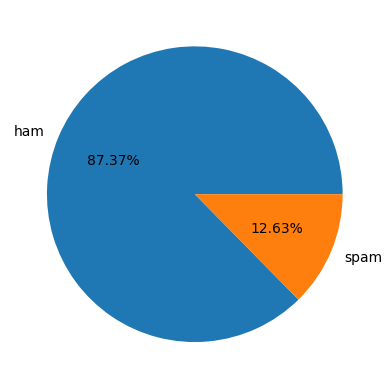

In [18]:
plt.pie(df['target'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f%%')
plt.show()

In [19]:
df['num_characters'] = df['message'].apply(len)

In [20]:
df.head()

,target,message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [3]:
import nltk

In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/omgupta/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
from nltk.tokenize import word_tokenize, sent_tokenize

df['word_count'] = df['message'].apply(lambda x: len(word_tokenize(x)))
df['sentence_count'] = df['message'].apply(lambda x: len(sent_tokenize(x)))

In [24]:
df.head()

,target,message,num_characters,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df.rename(columns = {'num_characters':'char_count'},inplace = True)

In [26]:
df.head()

,target,message,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['char_count','word_count','sentence_count']].describe()

,char_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
df[df['target'] == 0][['char_count','word_count','sentence_count']].describe()

,char_count,word_count,sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
df[df['target'] == 1][['char_count','word_count','sentence_count']].describe()

,char_count,word_count,sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [30]:
import seaborn as sns

<Axes: xlabel='char_count', ylabel='Count'>

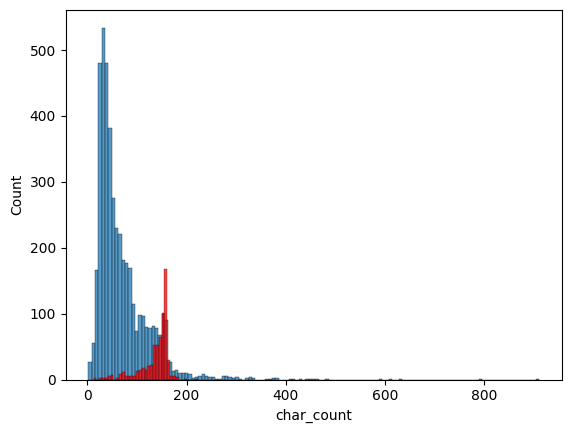

In [31]:
sns.histplot(df[df['target'] == 0]["char_count"]) # ham
sns.histplot(df[df['target'] == 1]["char_count"],color = 'red') # spam

<Axes: xlabel='word_count', ylabel='Count'>

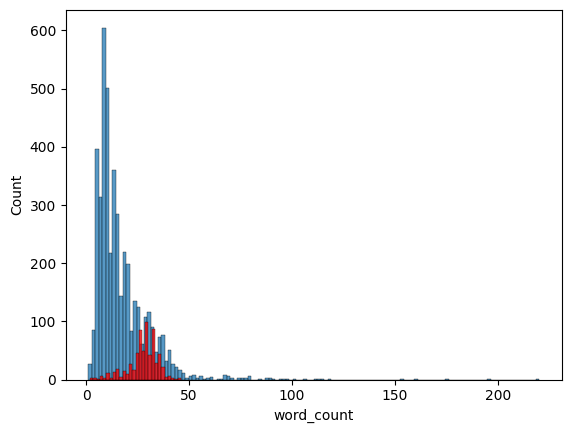

In [32]:
sns.histplot(df[df['target'] == 0]["word_count"]) # ham
sns.histplot(df[df['target'] == 1]["word_count"],color = 'red') # spam

In [33]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

ps = PorterStemmer()

def transform_text(msg):
    msg = msg.lower() # lowercase
    msg = word_tokenize(msg) # tokenization

    words = []
    stop_words = set(stopwords.words('english'))
    
    for w in msg:
        # remove punctuations and stopwords
        if w.isalnum() and w not in stop_words:
            words.append(w)

    msg = words[:]
    words.clear()

    for w in msg:
        # stemming
        words.append(ps.stem(w))

    return ' '.join(words)
    

In [34]:
df['transformed_message'] = df['message'].apply(transform_text)

In [35]:
df.head()

,target,message,char_count,word_count,sentence_count,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [36]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [38]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

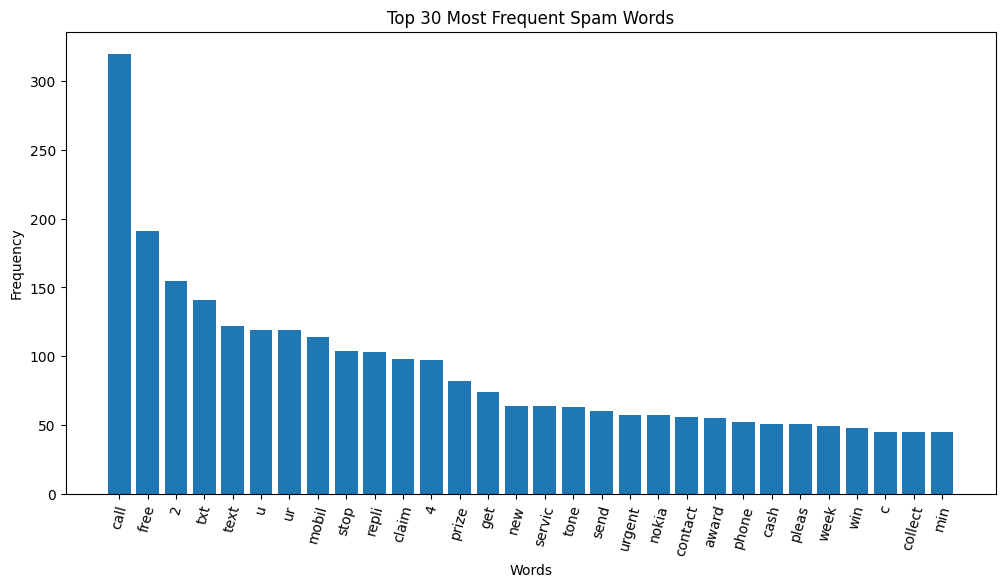

In [40]:
from collections import Counter

word_freq = Counter(spam_corpus)

top_30 = word_freq.most_common(30)

# Separate words and counts
labels = [item[0] for item in top_30]
counts = [item[1] for item in top_30]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(labels, counts)
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Frequent Spam Words")
plt.show()


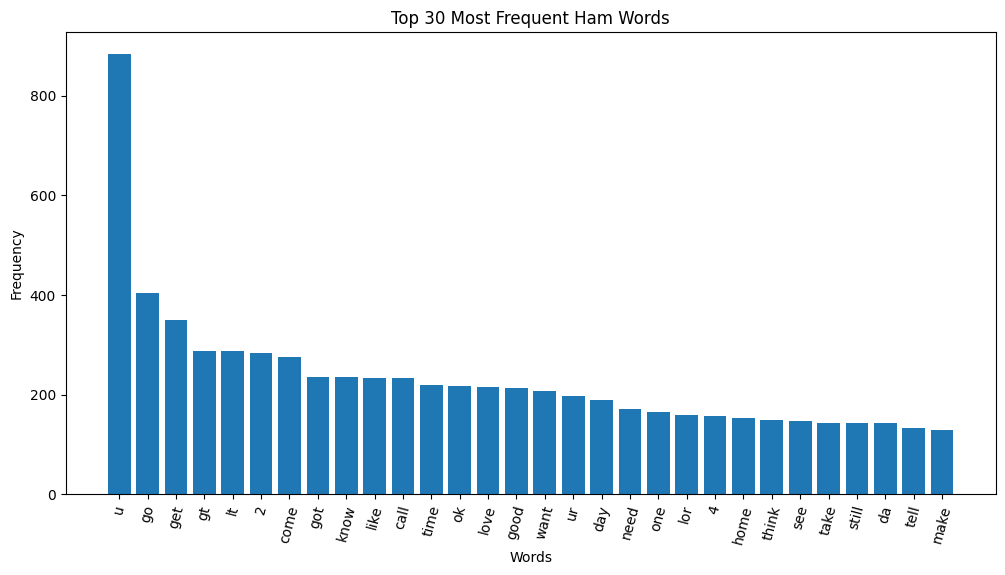

In [41]:
from collections import Counter

word_freq = Counter(ham_corpus)

top_30 = word_freq.most_common(30)

# Separate words and counts
labels = [item[0] for item in top_30]
counts = [item[1] for item in top_30]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(labels, counts)
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Frequent Ham Words")
plt.show()

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer(max_features=3000)

In [44]:
x = tfidf.fit_transform(df['transformed_message']).toarray()

In [45]:
x.shape

(5169, 3000)

In [46]:
y = df['target'].values

In [47]:
y 

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)

In [6]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [51]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [7]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [53]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print('Accuracy score: ',accuracy_score(y_test,y_pred1))
print('Precision score: ',precision_score(y_test,y_pred1))
print('Confusion matrix ')
print(confusion_matrix(y_test,y_pred1))

Accuracy score:  0.8694390715667312
Precision score:  0.5068493150684932
Confusion matrix 
[[788 108]
 [ 27 111]]


In [54]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print('Accuracy score: ',accuracy_score(y_test,y_pred2))
print('Precision score: ',precision_score(y_test,y_pred2))
print('Confusion matrix ')
print(confusion_matrix(y_test,y_pred2))

Accuracy score:  0.9709864603481625
Precision score:  1.0
Confusion matrix 
[[896   0]
 [ 30 108]]


In [55]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print('Accuracy score: ',accuracy_score(y_test,y_pred3))
print('Precision score: ',precision_score(y_test,y_pred3))
print('Confusion matrix ')
print(confusion_matrix(y_test,y_pred3))

Accuracy score:  0.9835589941972921
Precision score:  0.991869918699187
Confusion matrix 
[[895   1]
 [ 16 122]]


In [56]:
# here precision is more important metrice than accuracy 

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [9]:
from sklearn.model_selection import GridSearchCV

In [59]:
lr = LogisticRegression(max_iter=1000)

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(x_train, y_train)
print("Best LR:", grid_lr.best_params_)

/Users/omgupta/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/omgupta/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/omgupta/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warn

Best LR: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [60]:
svc = SVC()

param_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(svc, param_svc, cv=3, scoring='accuracy', n_jobs=-1)
grid_svc.fit(x_train, y_train)
print("Best SVC:", grid_svc.best_params_)

Best SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [61]:
mnb = MultinomialNB()

param_mnb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_mnb = GridSearchCV(mnb, param_mnb, cv=3, scoring='accuracy', n_jobs=-1)
grid_mnb.fit(x_train, y_train)
print("Best MNB:", grid_mnb.best_params_)

Best MNB: {'alpha': 0.1}


In [62]:
knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_knn, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(x_train, y_train)
print("Best KNN:", grid_knn.best_params_)

Best KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [63]:
dt = DecisionTreeClassifier()

param_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,5,10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt, param_dt, cv=3, scoring='accuracy', n_jobs=-1)
grid_dt.fit(x_train, y_train)
print("Best DT:", grid_dt.best_params_)

Best DT: {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2}


In [64]:
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf, param_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(x_train, y_train)
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [65]:
bc = BaggingClassifier()

param_bc = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

grid_bc = GridSearchCV(bc, param_bc, cv=3, scoring='accuracy', n_jobs=-1)
grid_bc.fit(x_train, y_train)
print("Best BC:", grid_bc.best_params_)

Best BC: {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}


In [66]:
etc = ExtraTreesClassifier()

param_etc = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_etc = GridSearchCV(etc, param_etc, cv=3, scoring='accuracy', n_jobs=-1)
grid_etc.fit(x_train, y_train)
print("Best ETC:", grid_etc.best_params_)

Best ETC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [67]:
gbc = GradientBoostingClassifier()

param_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_gbc = GridSearchCV(gbc, param_gbc, cv=3, scoring='accuracy', n_jobs=-1)
grid_gbc.fit(x_train, y_train)
print("Best GBC:", grid_gbc.best_params_)

Best GBC: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [68]:
abc = AdaBoostClassifier()

param_abc = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

grid_abc = GridSearchCV(abc, param_abc, cv=3, scoring='accuracy', n_jobs=-1)
grid_abc.fit(x_train, y_train)
print("Best ABC:", grid_abc.best_params_)

Best ABC: {'learning_rate': 1, 'n_estimators': 200}


In [69]:
lr = LogisticRegression(C = 10, penalty = 'l2', solver = 'lbfgs')
svc = SVC(C = 1,gamma = 'scale', kernel = 'linear')
mnb = MultinomialNB(alpha = 0.1)
knn = KNeighborsClassifier(metric = 'euclidean', n_neighbors = 3, weights = 'distance')
dt = DecisionTreeClassifier(criterion = 'gini', max_depth = 20, min_samples_split = 2)
rf = RandomForestClassifier(max_depth = None, max_features = 'sqrt', n_estimators = 100)
bc = BaggingClassifier(max_features = 0.5, max_samples = 1.0, n_estimators = 50)
etc = ExtraTreesClassifier(max_depth = None, max_features = 'sqrt', n_estimators = 200)
gbc = GradientBoostingClassifier(learning_rate = 0.1, max_depth = 3, n_estimators = 200)
abc = AdaBoostClassifier(learning_rate = 1, n_estimators = 200)

In [70]:
clfs = {
    'SVC' : svc,
    'KN' : knn, 
    'NB': mnb, 
    'DT': dt, 
    'LR': lr, 
    'RF': rf, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbc
}

In [49]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    Accuracy = accuracy_score(y_test,y_pred)
    Precision = precision_score(y_test,y_pred)

    return Accuracy,Precision

In [72]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    curr_accuracy_score,curr_precision_score = train_classifier(clf,x_train,y_train,x_test,y_test)
    accuracy_scores.append(curr_accuracy_score)
    precision_scores.append(curr_precision_score)



/Users/omgupta/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [75]:
performance = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [76]:
performance

,Algorithm,Accuracy,Precision
1,KN,0.927466,1.000000
8,ETC,0.978723,0.983333
7,BgC,0.977756,0.983193
0,SVC,0.978723,0.975410
2,NB,0.980658,0.968254
5,RF,0.973888,0.966387
4,LR,0.972921,0.966102
9,GBDT,0.955513,0.918182
6,AdaBoost,0.943907,0.884615
3,DT,0.952611,0.850394


In [10]:
# voting ensemble
from sklearn.ensemble import VotingClassifier

In [84]:
estimators = [('KN',knn),('ETC',etc),('MNB',mnb)]

In [85]:
vc = VotingClassifier(estimators,voting = 'soft')

In [86]:
vc.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('KN', ...), ('ETC', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2


In [87]:
y_pred = vc.predict(x_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision score:",precision_score(y_test,y_pred))

Accuracy score: 0.9738878143133463
Precision score: 1.0


In [88]:
#stacking
final_estimator = svc

In [89]:
from sklearn.ensemble import StackingClassifier
sc = StackingClassifier(estimators = estimators,final_estimator = final_estimator)

In [90]:
sc.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('KN', ...), ('ETC', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","SVC(C=1, kernel='linear')"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionbo

In [91]:
y_pred = sc.predict(x_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision score:",precision_score(y_test,y_pred))

Accuracy score: 0.9825918762088974
Precision score: 0.9761904761904762


In [92]:
# cross checking voting ensemble precision using cross validation

from sklearn.model_selection import cross_val_score
scores = cross_val_score(vc, x, y, cv=5, scoring='precision')
print(scores.mean())

1.0


In [ ]:
# voting classifier performs best

In [93]:
import pickle

In [94]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(vc,open('model.pkl','wb'))

In [4]:
sms = pd.read_csv("https://huggingface.co/datasets/thehamkercat/telegram-spam-ham/resolve/main/dataset.csv")
sms

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...
...,...,...
20343,ham,/ban
20344,ham,/ban
20345,ham,/ban
20346,ham,Kaisi hii


In [5]:
sms.isna().sum()

text_type    0
text         0
dtype: int64

In [7]:
sms.duplicated().sum()

np.int64(14)

In [8]:
sms = sms.drop_duplicates()

In [9]:
sms["text_type"].value_counts()

text_type
ham     14323
spam     6011
Name: count, dtype: int64

In [1]:
import matplotlib.pyplot as plt

In [11]:
plt.pie(sms['text_type'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f%%')
plt.show()

NameError: name 'sms' is not defined

In [12]:
df1 = pd.read_csv('spam.csv',encoding="latin1")
df2 = pd.read_csv("https://huggingface.co/api/resolve-cache/datasets/thehamkercat/telegram-spam-ham/dbf0a97b4b8cb0a8223378c85b6fc7e4526d43fb/dataset.csv")

In [13]:
df1.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [14]:
df1.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [15]:
df1.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df2.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [17]:
df1.rename(columns={
    "v1": "label",
    "v2": "message"
}, inplace=True)

df2.rename(columns={
    "text_type": "label",
    "text": "message"
}, inplace=True)

In [18]:
df1.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df2.head()

,label,message
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [20]:
merged_df = pd.concat([df1, df2], ignore_index=True)

In [21]:
merged_df.drop_duplicates(
    subset="message",
    inplace=True
)

In [22]:
merged_df["label"].value_counts()

label
ham     18831
spam     6661
Name: count, dtype: int64

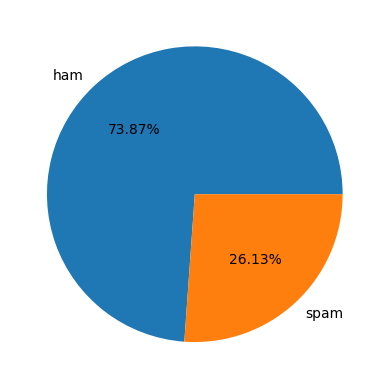

In [23]:
plt.pie(merged_df['label'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f%%')
plt.show()

In [24]:
merged_df.to_csv(
    "merged_dataset.csv",
    index=False
)

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged_df['label'] = le.fit_transform(merged_df['label'])

In [26]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

ps = PorterStemmer()

def transform_text(msg):
    msg = msg.lower() # lowercase
    msg = word_tokenize(msg) # tokenization

    words = []
    stop_words = set(stopwords.words('english'))
    
    for w in msg:
        # remove punctuations and stopwords
        if w.isalnum() and w not in stop_words:
            words.append(w)

    msg = words[:]
    words.clear()

    for w in msg:
        # stemming
        words.append(ps.stem(w))

    return ' '.join(words)

In [27]:
merged_df["transformed_message"] = merged_df["message"].apply(transform_text)

In [28]:
merged_df.head()

,label,message,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    merged_df["transformed_message"],
    merged_df["label"],
    test_size=0.2,
    stratify=merged_df["label"],
    random_state=42
)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

### Model Selection

In [31]:
svc = SVC()

param_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(svc, param_svc, cv=3, scoring='accuracy', n_jobs=-1)
grid_svc.fit(X_train, y_train)
print("Best SVC:", grid_svc.best_params_)

Best SVC: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [32]:
mnb = MultinomialNB()

param_mnb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_mnb = GridSearchCV(mnb, param_mnb, cv=3, scoring='accuracy', n_jobs=-1)
grid_mnb.fit(X_train, y_train)
print("Best MNB:", grid_mnb.best_params_)

Best MNB: {'alpha': 0.1}


In [33]:
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf, param_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}


In [34]:
bc = BaggingClassifier()

param_bc = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

grid_bc = GridSearchCV(bc, param_bc, cv=3, scoring='accuracy', n_jobs=-1)
grid_bc.fit(X_train, y_train)
print("Best BC:", grid_bc.best_params_)

Best BC: {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 100}


In [35]:
etc = ExtraTreesClassifier()

param_etc = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_etc = GridSearchCV(etc, param_etc, cv=3, scoring='accuracy', n_jobs=-1)
grid_etc.fit(X_train, y_train)
print("Best ETC:", grid_etc.best_params_)

Best ETC: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [36]:
knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_knn, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print("Best KNN:", grid_knn.best_params_)

Best KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [37]:
svc = SVC(C= 10, gamma = 'scale', kernel = 'rbf',probability=True)
mnb = MultinomialNB(alpha = 0.1)
rf = RandomForestClassifier(max_depth = None, max_features = 'log2', n_estimators = 200)
bc = BaggingClassifier(max_features = 0.5, max_samples = 1.0, n_estimators = 100)
etc = ExtraTreesClassifier(max_depth = None, max_features = 'sqrt', n_estimators = 200) 
knn = KNeighborsClassifier(metric = 'euclidean', n_neighbors = 3, weights = 'distance') 

In [38]:
clfs = {
    'SVC' : svc,
    'KNN' : knn, 
    'NB': mnb, 
    'RF': rf, 
    'BgC': bc, 
    'ETC': etc
}

In [39]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    Accuracy = accuracy_score(y_test,y_pred)
    Precision = precision_score(y_test,y_pred)

    return Accuracy,Precision

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    curr_accuracy_score,curr_precision_score = train_classifier(clf,X_train,y_train,X_test,y_test)
    accuracy_scores.append(curr_accuracy_score)
    precision_scores.append(curr_precision_score)

performance = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)


/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [40]:
performance

,Algorithm,Accuracy,Precision
3,RF,0.958227,0.976982
0,SVC,0.965287,0.961631
1,KNN,0.879780,0.961489
5,ETC,0.960973,0.953563
4,BgC,0.958423,0.950886
2,NB,0.934889,0.882848


In [41]:
estimators = [('ETC',etc),('RF',rf),('SVC',svc)]

In [42]:
vc = VotingClassifier(estimators=estimators,voting="soft")
vc.fit(X_train,y_train)

/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('ETC', ...), ('RF', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[ExtraTreesCla...stimators=200), RandomForestC...stimators=200), SVC(C=10, probability=True)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,3000


In [43]:
y_pred = vc.predict(X_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision score:",precision_score(y_test,y_pred))

Accuracy score: 0.9678368307511277
Precision score: 0.964968152866242


In [44]:
final_estimator = knn

from sklearn.ensemble import StackingClassifier
sc = StackingClassifier(estimators = estimators,final_estimator = final_estimator)
sc.fit(X_train,y_train)

/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/omgupta/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarn

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('ETC', ...), ('RF', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",KNeighborsCla...ts='distance')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[ExtraTreesCla...stimators=200), RandomForestC...stimators=200), SVC(C=10, probability=True)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,KNeighborsClassifier,KNeighborsCla...ts='distance')


In [46]:
y_pred = sc.predict(X_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Precision score:",precision_score(y_test,y_pred))

Accuracy score: 0.9595999215532457
Precision score: 0.9304281345565749


In [47]:
from sklearn.metrics import classification_report

models = {
    "RF": rf,
    "SVC": svc,
    "Voting": vc
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


RF
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3767
           1       0.98      0.86      0.91      1332

    accuracy                           0.96      5099
   macro avg       0.96      0.93      0.94      5099
weighted avg       0.96      0.96      0.96      5099


SVC
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3767
           1       0.96      0.90      0.93      1332

    accuracy                           0.97      5099
   macro avg       0.96      0.95      0.95      5099
weighted avg       0.97      0.97      0.96      5099


Voting
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3767
           1       0.96      0.91      0.94      1332

    accuracy                           0.97      5099
   macro avg       0.97      0.95      0.96      5099
weighted avg       0.97      0.97      0.97      5099



In [48]:
import pickle

pickle.dump(tfidf,open('vectorizer2.pkl','wb'))
pickle.dump(vc,open('model2.pkl','wb'))

In [50]:
import joblib

joblib.dump(vc, "model2.joblib", compress=9)

['model2.joblib']

In [51]:
print(tfidf.max_features)
print(X_train.shape)

print(rf)
print(etc)

3000
(20393, 3000)
RandomForestClassifier(max_features='log2', n_estimators=200)
ExtraTreesClassifier(n_estimators=200)
